# 🌡️ CARNOT TOOLS — Conversão de Temperatura
---
Copyright (C) 2026 Roberto Baginski Batista Santos - Prof.Baginski@gmail.com

Este programa é um software livre; você pode redistribuí-lo e/ou
modificá-lo sob os termos da Licença Pública Geral GNU como publicada
pela Free Software Foundation; tanto a versão 3 da Licença, ou
(a seu critério) qualquer versão posterior.

Este programa é distribuído na expectativa de que seja útil,
mas SEM NENHUMA GARANTIA; sem mesmo a garantia implícita de
COMERCIALIZAÇÃO ou de ADEQUAÇÃO A QUALQUER PROPÓSITO EM PARTICULAR.
Veja a Licença Pública Geral GNU para mais detalhes.

Você deve ter recebido uma cópia da Licença Pública Geral GNU junto
com este programa. Se não, veja https://www.gnu.org/licenses/gpl-3.0.html.

---
Esta ferramenta converte temperaturas entre seis escalas
termométricas: **Kelvin (K)**, **Celsius (°C)**, **Fahrenheit (°F)**,
**elétron-volt (eV/k<sub>B</sub>)**, **Rankine (°Ra)** e **Réaumur (°Ré)**.

A escala **Kelvin** é a mais usada na ciência e na tecnologia, sendo preconizada pelo Sistema Internacional de Unidades (SI) como padrão global para medidas de temperatura. Nesta escala, a unidade de temperatura é o kelvin (K) e a menor temperatura possível corresponde a $0\,\mathrm{K}$, o que a faz ser considerada uma **escala absoluta**, isto é, que não possui valores negativos. Na versão mais recente do SI, de 2019, cada aumento de $1\,\mathrm{K}$ na temperatura corresponde a uma variação de  $k_BT=1{,}380\ 649\times10^{-23}\mathrm{J}$ em que $k_B=1{,}380649\times10^{-23}\mathrm{J/K}$ é a **constante de Boltzmann**.

Quanto às demais escalas:
- a escala **Celsius** é usada cotidianamente em quase todo o mundo;
- a escala **Fahrenheit** ainda é usada cotidianamente em alguns poucos países como EUA, Bahamas e Palau;
- a escala **elétron-volt** é usada na física de partículas, na física de plasmas e na astrofísica, áreas em que é comum indicar temperaturas em eV, ficando subentendido que se trata, na verdade, da energia térmica das partículas. Preferimos indicar mais claramente que a unidade de medida de temperatura nesta escala é, na verdade, eV/k<sub>B</sub> em vez de usar apenas eV;   
- a escala **Rankine** é usada em indústrias específicas que precisam de uma escala absoluta, mas com intervalos entre os graus equivalentes aos da escala Fahrenheit;
- a escala **Réaumur** ainda é usada, por motivos puramente históricos, em aplicações como a medição da temperatura do leite na fabricação de queijos em certas regiões do norte da Itália.
  

### Escalas e pontos termométricos padrão da água

| Escala | Símbolo de unidade | Zero absoluto | Fusão do gelo | Ebulição da água |
|---|:---:|:---:|:---:|:---:|
| Kelvin | K | 0 | 273,15 | 373,15 |
| Celsius | °C | −273,15 | 0 | 100 |
| Fahrenheit | °F | −459,67 | 32 | 212 |
| elétron-volt | eV/k<sub>B</sub> | 0 | ≈ 0,02354 | ≈ 0,03216 |
| Rankine | °Ra | 0 | 491,67 | 671,67 |
| Réaumur | °Ré | −218,52 | 0 | 80 |


### Equações de conversão entre as escalas

As equações de conversão a partir da temperatura $T$ na escala Kelvin são:

- Celsius: $T_\mathrm{°C} = T - 273{,}15$
- Fahrenheit: $T_\mathrm{°F} = \frac{9}{5}\,T - 459{,}67$
- elétron-volt: $T_\mathrm{eV} = k_B T=8{,}617\ 333\ 262\times10^{-5}\ \text{eV/K}$
- Rankine: $T_\mathrm{°Ra} = \frac{9}{5}\,T$
- Réaumur: $T_\mathrm{°Ré} = \frac{4}{5}\,(T - 273{,}15)$

Na equação de conversão entre as escalas Kelvin e elétron-volt, usa-se a constante de Boltzmann em $\mathrm{eV/K}$. A conversão entre $\mathrm{J}$ e $\mathrm{eV}$ depende ainda do valor da carga elementar
$e = 1{,}602\ 176\ 634\times10^{-19}\,\text{C}$.

---
**Como usar:**
Execute a **Célula 1** — a interface aparece logo abaixo. Digite o
valor da temperatura (aceita vírgula ou ponto como separador decimal),
escolha a escala de origem no menu suspenso e clique em **Converter**.
A ferramenta exibe uma tabela com o valor convertido em todas as
escalas, além das equações que levam da escala escolhida a cada uma
das demais.

---
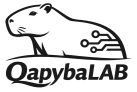

**https://github.com/rbaginski/QapybaLAB**

In [ ]:
#@title Execute esta célula para abrir a ferramenta **CARNOT TOOLS &mdash; Conversão de Temperatura**
# ── Célula 1: conversão de temperatura ───────────────────────────
# A ferramenta foi especificada pelo licenciante, incluindo escalas, métodos,
# pacotes a serem usados e linhas gerais da interface gráfica, mas a maior
# parte do código, especialmente as funções para a interface gráfica, foi
# escrita usando o modelo Claude Sonnet 4.6.


import math
import ipywidgets as w
from IPython.display import display, HTML, clear_output

# ══════════════════════════════════════════════════════════════════
#  ESTILOS CSS
#  Convenção compartilhada por toda a suíte QapybaLAB:
#    .sec   → rótulo de seção (cor = acento do app)
#    .rcard → card de resultado/destaque (cor = acento do app)
#    .gcard → card de "sucesso" (verde fixo)
#    .bcard → card informativo secundário (azul fixo)
#    .wcard → card de aviso (laranja fixo)
#    .ecard → card de erro (vermelho fixo)
#    .icard → card informativo auxiliar (cor = acento do app)
#  Acento desta ferramenta (CARNOT TOOLS): vermelho-fogo #e03131
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<style>
.sec{font-weight:700;font-size:.75rem;letter-spacing:.08em;color:#e03131;
  text-transform:uppercase;margin:13px 0 3px;}
.rcard{background:#fff0f0;border-left:4px solid #e03131;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.92rem;}
.gcard{background:#f0fff4;border-left:4px solid #2f9e44;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.92rem;}
.bcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.92rem;}
.wcard{background:#fff9db;border-left:4px solid #e67700;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.ecard{background:#fff0f0;border-left:4px solid #c92a2a;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.icard{background:#fff0f0;border-left:4px solid #e03131;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.88rem;}
.temp-t{border-collapse:collapse;font-size:.9rem;width:78%;margin:6px 0;}
.temp-t th{background:#1a1a2e;color:#fff;padding:6px 14px;text-align:center;}
.temp-t td{padding:6px 14px;border-bottom:1px solid #eee;
  font-family:monospace;text-align:center;}
.temp-t tr:nth-child(even) td{background:#fff3f3;}
.eq-box{background:#1a1a2e;color:#d8d8ff;font-family:monospace;
  font-size:.93rem;padding:10px 16px;border-radius:8px;
  margin:8px 0;line-height:1.9;}
</style>
"""))

# ══════════════════════════════════════════════════════════════════
#  CONSTANTE FÍSICA
#  Constante de Boltzmann k_B — valor EXATO fixado na revisão de 2019
#  do Sistema Internacional (SI), em vigor desde 20/05/2019.
#  k_B = 1.380649×10⁻²³ J/K  (exato, por definição)
#  e   = 1.602176634×10⁻¹⁹ C (carga elementar, exata, por definição)
#  k_B/e = 8.617333262×10⁻⁵ eV/K  (exato, decorre das duas definições)
# ══════════════════════════════════════════════════════════════════
KB_JK   = 1.380649e-23      # J/K  (exato, SI 2019)
E_CARGA = 1.602176634e-19   # C    (exato, SI 2019)
KB_EVK  = KB_JK / E_CARGA   # eV/K (≈ 8.617333262e-5)

# ══════════════════════════════════════════════════════════════════
#  ESCALAS — ordem fixa usada em toda a interface
# ══════════════════════════════════════════════════════════════════
ORDEM = ["K", "C", "F", "eV", "Ra", "Re"]

RÓTULO = {
    "K":  "Kelvin (K)",
    "C":  "Celsius (°C)",
    "F":  "Fahrenheit (°F)",
    "eV": "elétron-volt (eV/k_B)",
    "Ra": "Rankine (°Ra)",
    "Re": "Réaumur (°Ré)",
}
UNIDADE = {"K": "K", "C": "°C", "F": "°F", "eV": "eV/k_B",
           "Ra": "°Ra", "Re": "°Ré"}
SIMBOLO_HTML = {"K": "T<sub>K</sub>", "C": "T<sub>C</sub>", "F": "T<sub>F</sub>",
                "eV": "T<sub>eV</sub>", "Ra": "T<sub>Ra</sub>",
                "Re": "T<sub>Ré</sub>"}

# ── conversões numéricas (todas passam pela escala absoluta Kelvin) ──
def para_kelvin(escala, x):
    if escala == "K":  return x
    if escala == "C":  return x + 273.15
    if escala == "F":  return (x - 32) * 5/9 + 273.15
    if escala == "eV": return x / KB_EVK
    if escala == "Ra": return x * 5/9
    if escala == "Re": return x * 5/4 + 273.15

def de_kelvin(escala, T):
    if escala == "K":  return T
    if escala == "C":  return T - 273.15
    if escala == "F":  return (T - 273.15) * 9/5 + 32
    if escala == "eV": return T * KB_EVK
    if escala == "Ra": return T * 9/5
    if escala == "Re": return (T - 273.15) * 4/5

def coef_conversao(escala_origem, escala_destino):
    """Como todas as conversões entre escalas termométricas são
    transformações afins (y = m·x + b), os coeficientes m e b são obtidos
    avaliando a composição para_kelvin→de_kelvin em dois pontos (0 e 1)."""
    b = de_kelvin(escala_destino, para_kelvin(escala_origem, 0.0))
    m = de_kelvin(escala_destino, para_kelvin(escala_origem, 1.0)) - b
    return m, b

def fmt_sig(v, sig=6):
    v = float(v)
    if not math.isfinite(v) or v == 0: return str(v)
    d = int(math.floor(math.log10(abs(v)))) - (sig - 1)
    return (f"{round(v,-d):.{max(0,-d)}f}" if d >= 0 else f"{v:.{-d}f}")

def fmt_num_html(v, sig=6):
    """Formata um número em HTML, usando notação científica com
    expoente sobrescrito para valores muito pequenos ou muito grandes
    (ex.: coeficiente da escala eV/k_B)."""
    v = float(v)
    if v == 0: return "0"
    neg, av = v < 0, abs(v)
    if 1e-3 <= av < 1e5:
        s = fmt_sig(av, sig)
        return ("−" if neg else "") + s
    expo = int(math.floor(math.log10(av)))
    mant = fmt_sig(av / (10 ** expo), sig)
    exp_s = f"−{abs(expo)}" if expo < 0 else f"{expo}"
    return ("−" if neg else "") + f"{mant} × 10<sup>{exp_s}</sup>"

def linha_equacao(escala_origem, escala_destino):
    """Monta, em HTML simples, a equação que converte da escala de
    origem para a escala de destino (ex.: 'T_C = T_K − 273.15')."""
    m, b = coef_conversao(escala_origem, escala_destino)
    origem_html  = SIMBOLO_HTML[escala_origem]
    destino_html = SIMBOLO_HTML[escala_destino]
    termo_m = origem_html if abs(m - 1.0) < 1e-9 \
        else f"{fmt_num_html(m)} · {origem_html}"
    if abs(b) < 1e-9:
        return f"{destino_html} = {termo_m}"
    sinal = "+" if b > 0 else "−"
    return f"{destino_html} = {termo_m} {sinal} {fmt_num_html(abs(b))}"

# ══════════════════════════════════════════════════════════════════
#  HTML HELPERS  (mesmos usados em toda a suíte QapybaLAB)
# ══════════════════════════════════════════════════════════════════
def h(tag, content, **attrs):
    a = " ".join(f'{k.rstrip("_")}="{v}"' for k, v in attrs.items())
    return f"<{tag} {a}>{content}</{tag}>"

def card(s, c="rcard"): return f'<div class="{c}">{s}</div>'

def sec_html(texto, estilo=""):
    extra = f' style="{estilo}"' if estilo else ""
    return f'<div class="sec"{extra}>{texto}</div>'

def titulo_secao(texto, estilo=""):
    return w.HTML(sec_html(texto, estilo))

def tabela_conversao_html(escala_origem, T_K):
    ths = "".join(h("th", t) for t in ["Escala", "Valor convertido"])
    rows = ""
    for escala in ORDEM:
        valor = de_kelvin(escala, T_K)
        destaque = 'style="background:#ffe3e3"' if escala == escala_origem else ""
        rows += f"<tr {destaque}>" + "".join(h("td", c) for c in [
            RÓTULO[escala],
            f"{fmt_sig(valor,6)} {UNIDADE[escala]}"]) + "</tr>"
    return h("table", h("thead", h("tr", ths)) + h("tbody", rows),
              class_="temp-t")

# ══════════════════════════════════════════════════════════════════
#  WIDGETS
# ══════════════════════════════════════════════════════════════════
ES = {"description_width": "160px"}

cabecalho = w.HTML(r'''
<div style="background: linear-gradient(135deg, #004587 0%, #00AB45 80%, #006EAB 100%);
            padding: 14px 20px; border-radius: 10px; color: white;
            font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 12px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.15);">
  <div style="font-size: 13px; letter-spacing: 3px; opacity: 0.85; font-weight: 600;">QapybaLAB &mdash; CARNOT TOOLS</div>
  <div style="font-size: 26px; font-weight: 700; margin-top: 2px;">🌡️ Conversão de Temperatura</div>
</div>
''')

display(w.VBox([cabecalho]))

# ── Entrada ──────────────────────────────────────────────────────
display(titulo_secao('⚙ Valor a converter'))

wvalor = w.Text(value="25", description="Temperatura:",
                style=ES, layout=w.Layout(width="260px"),
                placeholder="ex: 25 ou 25,3")
wescala = w.Dropdown(
    options=[(RÓTULO[e], e) for e in ORDEM],
    value="C", description="Escala de origem:",
    style={"description_width": "150px"},
    layout=w.Layout(width="340px"))
display(w.HBox([wvalor, wescala]))
display(w.HTML(
    '<small style="color:#888">O separador decimal pode ser vírgula '
    'ou ponto (ex: 36,5 ou 36.5).</small>'))

btn = w.Button(description="🌡️ Converter", button_style="danger",
               layout=w.Layout(width="200px", height="40px"))
saida = w.Output()
display(w.HBox([btn]), saida)

# ══════════════════════════════════════════════════════════════════
#  CALLBACK PRINCIPAL
#  Toda a saída é montada em uma única string HTML e exibida com uma
#  única chamada display(HTML(...)) — ver nota de robustez no topo.
# ══════════════════════════════════════════════════════════════════
def _on_converter(_):
    with saida:
        clear_output(wait=True)

        texto  = wvalor.value.strip().replace(",", ".")
        escala = wescala.value

        if not texto:
            display(HTML(card("⚠ Digite o valor da temperatura.", "wcard")))
            return
        try:
            valor = float(texto)
        except ValueError:
            display(HTML(card(
                f"✘ '{wvalor.value}' não é um número válido. "
                f"Use vírgula ou ponto como separador decimal.", "ecard")))
            return

        # ── Verifica se o valor respeita o zero absoluto ──────
        T_K = para_kelvin(escala, valor)
        if T_K < -1e-6:
            display(HTML(card(
                f"✘ Este valor corresponde a {fmt_sig(T_K,6)} K, "
                f"abaixo do zero absoluto (0 K). Não é uma temperatura "
                f"fisicamente válida.", "ecard")))
            return
        T_K = max(T_K, 0.0)

        # ── Monta as equações de conversão a partir da escala escolhida ─
        eqs = [linha_equacao(escala, destino)
               for destino in ORDEM if destino != escala]

        # ── Monta TODA a saída em uma única string HTML ────────
        partes = [
            sec_html('📊 Temperatura convertida em todas as escalas'),
            tabela_conversao_html(escala, T_K),

            sec_html('✔ Resultado'),
            card(
                f"<b>{fmt_sig(valor,6)} {UNIDADE[escala]}</b> "
                f"&nbsp;=&nbsp; <b>{fmt_sig(T_K,6)} K</b>", "gcard"),

            sec_html(f'📐 Equações de conversão a partir de {RÓTULO[escala]}'),
            f'<div class="eq-box">' + "<br>".join(eqs) + "</div>",

            card(
                "A escala elétron-volt (eV/k_B) expressa a temperatura "
                "como a energia térmica k_B·T, medida em eV. Usa-se a "
                "constante de Boltzmann k_B = 1,380649×10⁻²³ J/K (valor "
                "exato, fixado na revisão de 2019 do SI) e a carga "
                "elementar e = 1,602176634×10⁻¹⁹ C (exata), o que fornece "
                "k_B = 8,617333262×10⁻⁵ eV/K (usado nas conversões acima).",
                "icard"),
        ]
        display(HTML("".join(partes)))

btn.on_click(_on_converter)
